<a href="https://colab.research.google.com/github/folonidaniel4/Redes-Neurais/blob/main/Classificador_de_Plantas_MLP_por_meio_da_Biblioteca_IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

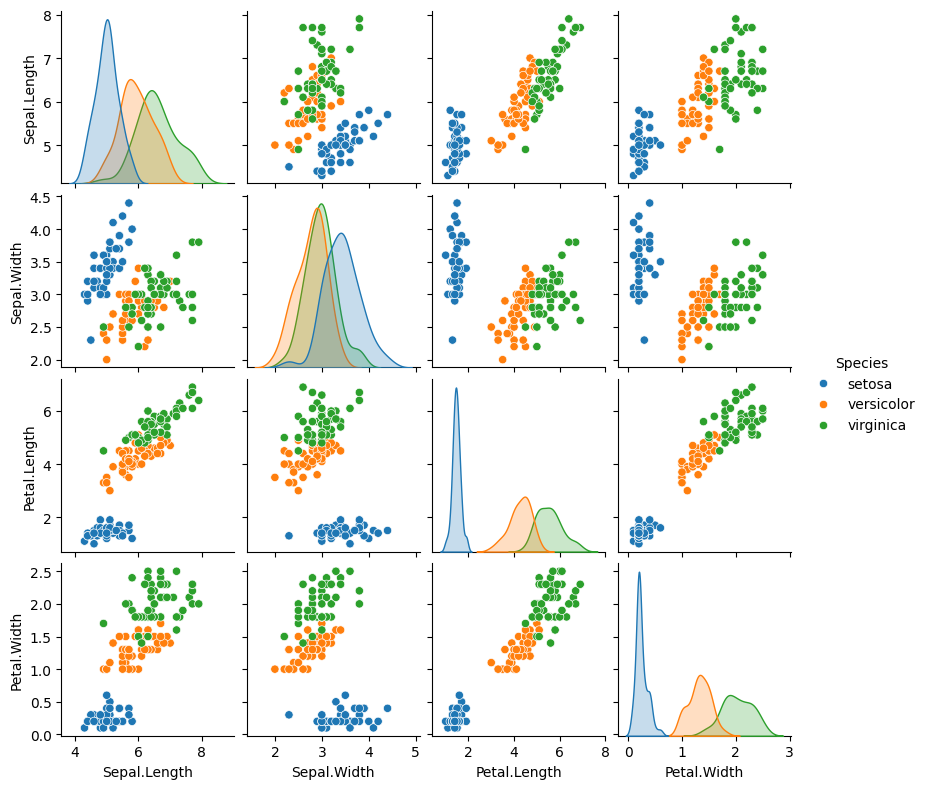

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Aprendizado_de_Maquina/main/Dados/iris.csv')
sns.pairplot(df, hue='Species', height=2)

In [3]:
#Codificando uma variável categórica para numérica
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Species'])

X = df[['Sepal.Length','Sepal.Width']]

#Dividir o conjunto de dados em conjunto de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Escalonar as características para ter média 0 e variância unitária
escala = StandardScaler()
X_train = escala.fit_transform(X_train)
X_test = escala.fit_transform(X_test)

In [4]:
#Criando um classificador MLP
mlp = MLPClassifier(hidden_layer_sizes=(15, 5, 3), activation='tanh', random_state=42)

#Ajustando o modelo MLP aos dados de treinamento
mlp.fit(X_train, y_train)

#Fazendo previsões nos dados de teste
y_predicao = mlp.predict(X_test)

#Calculando a precisão do modelo
acurando = accuracy_score(y_test, y_predicao)
print('Acurácia: ',acurando)


Acurácia:  0.9


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


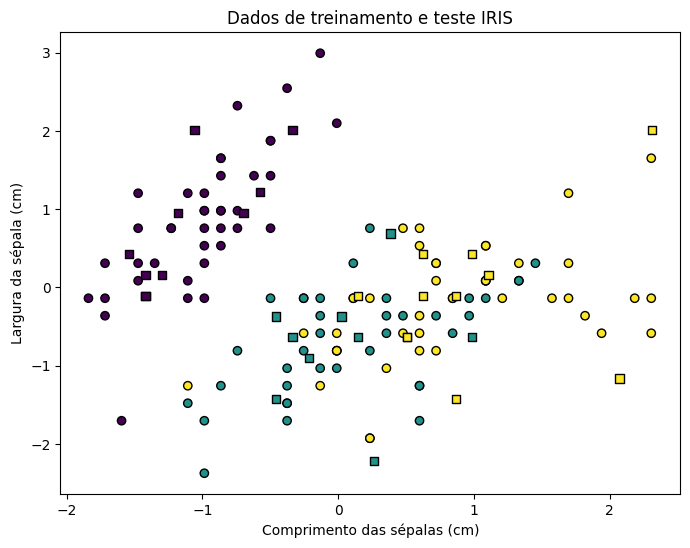

In [5]:
#Plotando os dados de treinamento e teste
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='viridis', edgecolors='k', label='Treinamento')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='viridis', marker='s', edgecolor='k',label='Teste')
plt.xlabel('Comprimento das sépalas (cm)')
plt.ylabel('Largura da sépala (cm)')
plt.title('Dados de treinamento e teste IRIS')
plt.show()